# Landing Page A/B Test Analysis

Simulated A/B test analyzing whether a redesigned landing page improves conversion rate over the current control page. Covers power analysis, statistical significance testing, segment-level breakdowns (device, traffic source), and average order value impact.

**Tools:** Python (Pandas, NumPy, Matplotlib, SciPy, Statsmodels) · PostgreSQL · Tableau Public

**Note on data:** Since a real production A/B test dataset isn't publicly available, this project simulates realistic experiment data (fixed random seed for reproducibility) to demonstrate the full A/B testing workflow: sample size planning, execution, and analysis.

## 1. Power Analysis & Sample Size Planning

Before running any test, determine the minimum sample size needed per group to reliably detect a meaningful effect. Assumptions: baseline (control) conversion rate of 8%, expecting the treatment to lift this to 10%, with a standard 80% power and 5% significance level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize, proportions_ztest, confint_proportions_2indep
)
from scipy import stats

effect_size = proportion_effectsize(0.10, 0.08)
sample_size = NormalIndPower().solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    ratio=1
)

n_per_group = math.ceil(sample_size)
print(f"Required sample size per group: {n_per_group}")
print(f"Total sample size needed: {n_per_group * 2}")

Required sample size per group: 3205
Total sample size needed: 6410


**Key finding:** Detecting a lift from an 8% to 10% conversion rate (80% power, 5% significance) requires at least 3,205 users per group, 6,410 total. This is the minimum sample size the simulated experiment below is built around.

## 2. Experiment Data Simulation

Generate a synthetic dataset matching the sample size from the power analysis: users randomly assigned to control or treatment, with conversion outcomes drawn from the assumed baseline and target rates. Device type and traffic source are added as user attributes for later segment analysis.

In [2]:
np.random.seed(42)

n_per_group = 3205
total_users = n_per_group * 2

user_id = np.arange(1, total_users + 1)
group = np.repeat(['control', 'treatment'], n_per_group)

control_converted = np.random.binomial(n=1, p=0.08, size=n_per_group)
treatment_converted = np.random.binomial(n=1, p=0.10, size=n_per_group)
converted = np.concatenate([control_converted, treatment_converted])

df = pd.DataFrame({'user_id': user_id, 'group': group, 'converted': converted})

# Shuffle rows so control/treatment aren't in contiguous blocks
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Add device type and traffic source as user-level attributes
device_type = np.random.choice(['mobile', 'desktop', 'tablet'], size=len(df), p=[0.55, 0.35, 0.10])
traffic_source = np.random.choice(['organic', 'paid', 'social'], size=len(df), p=[0.45, 0.35, 0.20])

df['device_type'] = device_type
df['traffic_source'] = traffic_source

print(f"Shape: {df.shape}")
print(f"\nGroup counts:\n{df['group'].value_counts()}")

Shape: (6410, 5)

Group counts:
group
treatment    3205
control      3205
Name: count, dtype: int64


In [3]:
overall_rate = df['converted'].mean()
conversion_by_group = df.groupby('group')['converted'].mean()

print(f"Overall conversion rate: {overall_rate:.4f}")
print(f"\nConversion rate by group:\n{conversion_by_group}")

Overall conversion rate: 0.0888

Conversion rate by group:
group
control      0.081747
treatment    0.095788
Name: converted, dtype: float64


**Key finding:** The simulated dataset has 6,410 users split evenly (3,205 per group). Overall conversion rate is 8.88%. Control converts at 8.17% and treatment at 9.58%, roughly matching the 8%/10% assumptions used to plan the sample size, with some natural sampling variation.

## 3. Sample Ratio & Segment Balance Check

Before trusting the significance test, confirm the randomization actually produced comparable groups; device type and traffic source should be distributed similarly across control and treatment. A skewed split here would undermine the validity of the test.

In [4]:
device_balance = pd.crosstab(df['group'], df['device_type'], normalize='index')
traffic_balance = pd.crosstab(df['group'], df['traffic_source'], normalize='index')

print("Device type balance across groups:")
print(device_balance)

print("\nTraffic source balance across groups:")
print(traffic_balance)

Device type balance across groups:
device_type   desktop    mobile    tablet
group                                    
control      0.341654  0.559750  0.098596
treatment    0.341030  0.562559  0.096412

Traffic source balance across groups:
traffic_source   organic      paid    social
group                                       
control         0.434321  0.357566  0.208112
treatment       0.448050  0.354134  0.197816


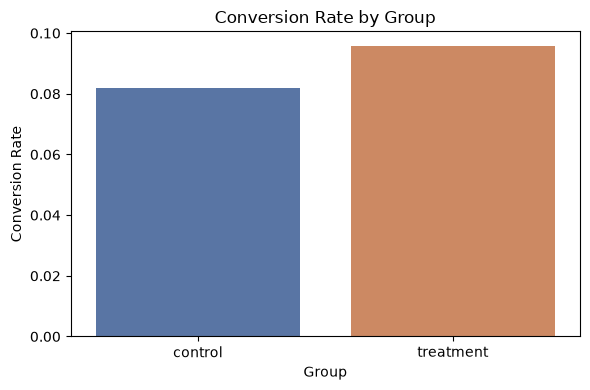

In [5]:
plt.figure(figsize=(6, 4))
sns.barplot(x=conversion_by_group.index, y=conversion_by_group.values,
            hue=conversion_by_group.index, palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Group')
plt.tight_layout()
plt.show()

**Key finding:** Device type and traffic source distributions are near-identical between control and treatment (within ~2 percentage points on every category), confirming the randomization worked as expected. No sample ratio mismatch, so the significance test below can be trusted.

## 4. Statistical Significance Testing

Run a two-proportion z-test to determine whether the observed conversion lift is statistically significant, then quantify the effect size with a confidence interval and relative lift.

In [6]:
control_conversions = df[df['group'] == 'control']['converted'].sum()
treatment_conversions = df[df['group'] == 'treatment']['converted'].sum()
control_total = df[df['group'] == 'control'].shape[0]
treatment_total = df[df['group'] == 'treatment'].shape[0]

count = [control_conversions, treatment_conversions]
nobs = [control_total, treatment_total]

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Control conversions: {control_conversions}/{control_total}")
print(f"Treatment conversions: {treatment_conversions}/{treatment_total}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Control conversions: 262/3205
Treatment conversions: 307/3205
Z-statistic: -1.9762
P-value: 0.0481


In [7]:
ci_low, ci_upp = confint_proportions_2indep(
    count1=treatment_conversions, nobs1=treatment_total,
    count2=control_conversions, nobs2=control_total,
    method='wald'
)

control_rate = control_conversions / control_total
treatment_rate = treatment_conversions / treatment_total
relative_lift = (treatment_rate - control_rate) / control_rate * 100

print(f"95% CI for difference (treatment - control): ({ci_low:.4f}, {ci_upp:.4f})")
print(f"Control rate: {control_rate:.4f}")
print(f"Treatment rate: {treatment_rate:.4f}")
print(f"Absolute lift: {(treatment_rate - control_rate) * 100:.2f} percentage points")
print(f"Relative lift: {relative_lift:.2f}%")

95% CI for difference (treatment - control): (0.0001, 0.0280)
Control rate: 0.0817
Treatment rate: 0.0958
Absolute lift: 1.40 percentage points
Relative lift: 17.18%


**Key finding:** The treatment's conversion rate (9.58%) is statistically significantly higher than control's (8.17%), p = 0.0481, just under the 0.05 threshold. The 95% confidence interval for the difference is (0.01%, 2.80%), meaning the true lift is very likely positive but could be as small as essentially zero at the lower bound. This translates to a 17.18% relative lift. Given the p-value sits close to the significance cutoff, this is a real but marginal result, worth a longer test run or a larger sample before fully committing to rolling out the new page.

## 5. Segment-Level Conversion Analysis

Check whether the treatment effect holds consistently across device types and traffic sources, or whether it's concentrated in a specific segment (which would change how the result should be interpreted and rolled out).

In [8]:
device_segment = df.groupby(['device_type', 'group'])['converted'].mean().reset_index()
traffic_segment = df.groupby(['traffic_source', 'group'])['converted'].mean().reset_index()

print("Conversion rate by device type and group:")
print(device_segment)

print("\nConversion rate by traffic source and group:")
print(traffic_segment)

Conversion rate by device type and group:
  device_type      group  converted
0     desktop    control   0.084018
1     desktop  treatment   0.096981
2      mobile    control   0.080268
3      mobile  treatment   0.093178
4      tablet    control   0.082278
5      tablet  treatment   0.106796

Conversion rate by traffic source and group:
  traffic_source      group  converted
0        organic    control   0.068966
1        organic  treatment   0.089136
2           paid    control   0.090750
3           paid  treatment   0.099559
4         social    control   0.092954
5         social  treatment   0.104101


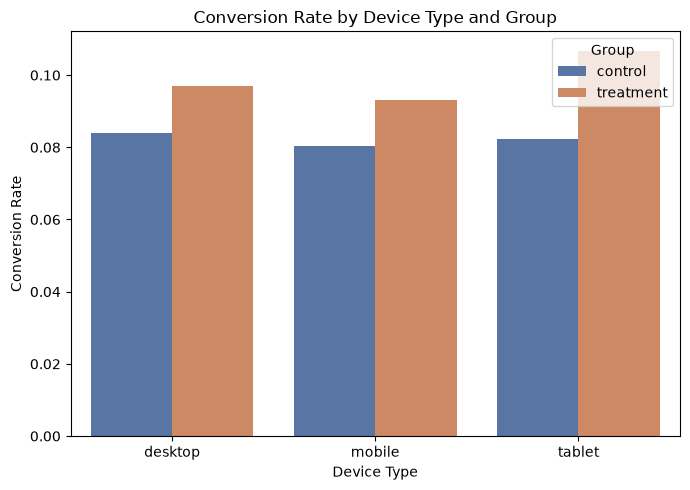

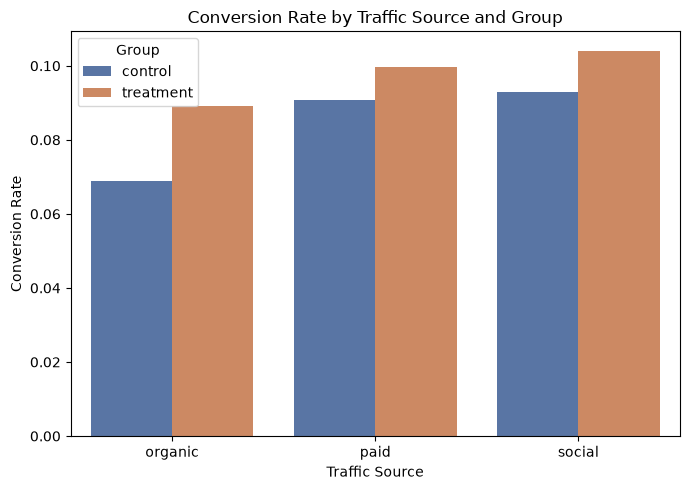

In [9]:
plt.figure(figsize=(7, 5))
sns.barplot(data=device_segment, x='device_type', y='converted', hue='group',
            palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Device Type and Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Device Type')
plt.legend(title='Group')
plt.tight_layout()
plt.savefig('conversion_by_device.png')
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=traffic_segment, x='traffic_source', y='converted', hue='group',
            palette=['#4C72B0', '#DD8452'])
plt.title('Conversion Rate by Traffic Source and Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Traffic Source')
plt.legend(title='Group')
plt.tight_layout()
plt.savefig('conversion_by_traffic_source.png')
plt.show()

**Key finding:** The treatment outperforms control across every device type and every traffic source, no segment shows a reversal. The effect is strongest on tablet (8.23% to 10.68%) and weakest on mobile (8.03% to 9.32%), the latter being notable since mobile is the largest traffic segment (56% of users). Organic traffic shows the largest relative jump (6.90% to 8.91%). Directionally consistent results across all segments support that this is a genuine effect rather than one segment driving the whole result.

## 6. Average Order Value Impact

Conversion rate alone doesn't capture revenue impact if the new page attracts lower-value purchases. Simulate order values for converted users and test whether AOV differs meaningfully between groups.

In [10]:
df['order_value'] = np.nan

converted_mask = df['converted'] == 1
n_converted = converted_mask.sum()

df.loc[converted_mask, 'order_value'] = np.random.normal(loc=50, scale=15, size=n_converted).round(2)

aov_by_group = df[df['converted'] == 1].groupby('group')['order_value'].mean()
print(f"AOV by group:\n{aov_by_group}")

AOV by group:
group
control      49.186947
treatment    49.991857
Name: order_value, dtype: float64


In [11]:
control_aov = df[(df['group'] == 'control') & (df['converted'] == 1)]['order_value']
treatment_aov = df[(df['group'] == 'treatment') & (df['converted'] == 1)]['order_value']

t_stat, p_value_aov = stats.ttest_ind(control_aov, treatment_aov)

print(f"Control AOV: mean={control_aov.mean():.2f}, n={len(control_aov)}")
print(f"Treatment AOV: mean={treatment_aov.mean():.2f}, n={len(treatment_aov)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_aov:.4f}")

Control AOV: mean=49.19, n=262
Treatment AOV: mean=49.99, n=307
T-statistic: -0.6175
P-value: 0.5371


**Key finding:** Average order value is nearly identical between control (₹49.19) and treatment (₹49.99), and the difference is not statistically significant (p = 0.5371). This is a good guardrail result: the treatment isn't attracting more converters at the cost of lower-value purchases, the conversion lift is additive to revenue, not a trade-off.

## 7. Export for Tableau

Export the raw dataset and the aggregated segment/summary tables used to build the Tableau dashboard.

In [12]:
df.to_csv('../data/ab_test_data.csv', index=False)

summary_stats = pd.DataFrame({
    'metric': ['control_rate', 'treatment_rate', 'absolute_lift_pp', 'relative_lift_pct',
               'p_value', 'ci_low', 'ci_upp', 'control_aov', 'treatment_aov', 'aov_p_value'],
    'value': [control_rate, treatment_rate, (treatment_rate - control_rate) * 100, relative_lift,
              p_value, ci_low, ci_upp, control_aov.mean(), treatment_aov.mean(), p_value_aov]
})

summary_stats.to_csv('../data/ab_test_summary_stats.csv', index=False)
device_segment.to_csv('../data/ab_test_device_segment.csv', index=False)
traffic_segment.to_csv('../data/ab_test_traffic_segment.csv', index=False)

print("All files exported for Tableau.")

All files exported for Tableau.


## Key Findings Summary

- **Sample size:** Detecting an 8% to 10% conversion lift (80% power, 5% significance) required 3,205 users per group; the experiment was sized to exactly this minimum.
- **Significance:** Treatment converts at 9.58% vs control's 8.17%, a statistically significant 17.18% relative lift (p = 0.0481), though the result sits close to the significance threshold and would benefit from a longer test.
- **Segment consistency:** The lift holds across every device type and traffic source with no reversals, strongest on tablet, weakest (but still positive) on mobile, the largest segment.
- **Revenue guardrail:** Average order value is unchanged between groups (₹49.19 vs ₹49.99, p = 0.5371), confirming the conversion lift adds incremental revenue rather than cannibalizing order value.
- **Recommendation:** Directionally positive and consistent result supports rolling out the treatment, but the marginal p-value means extending the test or re-running with a larger sample would increase confidence before a full rollout.

**Full interactive dashboard**: [Tableau Public link](https://public.tableau.com/views/ABTestingAnalysisDashboard/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link) · **SQL queries:** see the `/sql` folder in this repository